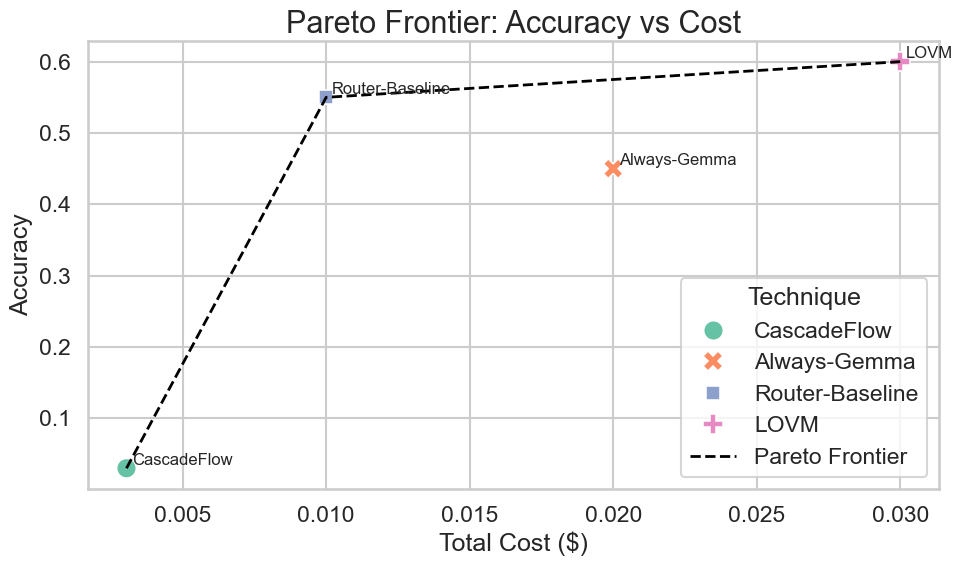

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ==========================================================
# 1. INSERT YOUR TECHNIQUES HERE
# ==========================================================

techniques = [
    {"name": "CascadeFlow",      "accuracy": 0.03, "cost": 0.00304194},
    {"name": "Always-Gemma",     "accuracy": 0.45, "cost": 0.020},
    {"name": "Router-Baseline",  "accuracy": 0.55, "cost": 0.010},
    {"name": "LOVM",             "accuracy": 0.60, "cost": 0.030},   # example
]

df = pd.DataFrame(techniques)

# ==========================================================
# 2. Compute Pareto frontier (maximize accuracy, minimize cost)
# ==========================================================

def pareto_front(df):
    pareto_mask = []
    for i, p in df.iterrows():
        dominated = False
        for j, q in df.iterrows():
            if i == j:
                continue
            if (q["accuracy"] >= p["accuracy"] and q["cost"] <= p["cost"]) and \
               (q["accuracy"] > p["accuracy"] or q["cost"] < p["cost"]):
                dominated = True
                break
        pareto_mask.append(not dominated)
    return df[pareto_mask]

pareto_df = pareto_front(df).sort_values("cost")

# ==========================================================
# 3. Beautiful Plot with Seaborn
# ==========================================================

sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(10, 6))

# Scatter plot of all techniques
scatter = sns.scatterplot(
    data=df,
    x="cost",
    y="accuracy",
    hue="name",
    style="name",
    s=200,
    palette="Set2",
    markers=True
)

# Draw the Pareto frontier line
plt.plot(
    pareto_df["cost"],
    pareto_df["accuracy"],
    color="black",
    linewidth=2,
    linestyle="--",
    label="Pareto Frontier"
)

# Annotate each point
for _, row in df.iterrows():
    plt.text(
        row["cost"] + 0.0002,
        row["accuracy"] + 0.005,
        row["name"],
        fontsize=12
    )

plt.title("Pareto Frontier: Accuracy vs Cost", fontsize=22)
plt.xlabel("Total Cost ($)", fontsize=18)
plt.ylabel("Accuracy", fontsize=18)
plt.legend(title="Technique")
plt.tight_layout()
plt.show()
